# EDA: ALI=F (Aluminum Futures)
### Exploratory Data Analysis - Ringkas & To-the-Point

**Tujuan:** Memahami kualitas dan karakteristik data untuk Machine Learning

**Dataset:** ALI=F (Futures Aluminium) dari Yahoo Finance

## 1️. Loading & Inspection

In [1]:
import yfinance as yf
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import warnings
warnings.filterwarnings('ignore')

# Download data
SYMBOL = "ALI=F"
df = yf.download(
    SYMBOL,
    start="2000-01-01",
    interval="1d",
    auto_adjust=False,
    repair=True,
    keepna=True,
    progress=False
)

# Flatten MultiIndex columns
if isinstance(df.columns, pd.MultiIndex):
    df.columns = [c[0] for c in df.columns]

# Clean and sort
df = df.sort_index()
df.index = pd.to_datetime(df.index)
df.index.name = "Date"

print(f"Data loaded: {df.shape[0]} rows × {df.shape[1]} columns")
print(f"Periode: {df.index.min().date()} s/d {df.index.max().date()}")
df.head()

Data loaded: 2980 rows × 7 columns
Periode: 2014-05-06 s/d 2026-03-04


,Adj Close,Close,High,Low,Open,Repaired?,Volume
Date,,,,,,,
2014-05-06,2172.75,2172.75,2205.75,2165.00,2182.75,False,41
2014-05-07,2149.00,2149.00,2152.25,2146.00,2152.25,False,35
2014-05-08,2141.75,2141.75,2150.00,2130.00,2150.00,False,25
2014-05-09,2107.25,2107.25,2133.50,2107.25,2133.50,False,14
2014-05-12,2088.25,2088.25,2088.25,2086.00,2086.00,False,4


## 2️. Data Quality Check (FASE TERPENTING!)

### 2.1 Missing Values

MISSING VALUES SUMMARY


,Missing Count,Percentage (%)
Adj Close,39,1.31
Close,39,1.31
High,39,1.31
Low,39,1.31
Open,39,1.31


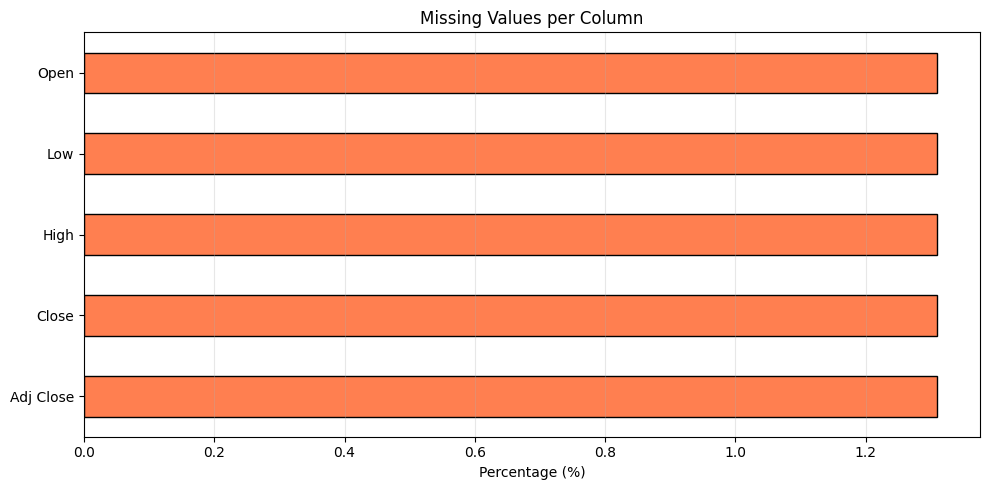


Close NaN: 39 tanggal
   Rentang: 2016-01-18 s/d 2023-11-23


In [2]:
# Missing value analysis
missing = df.isna().sum()
missing_pct = round(missing / len(df) * 100, 2)

missing_df = pd.DataFrame({
    'Missing Count': missing,
    'Percentage (%)': missing_pct
}).sort_values('Percentage (%)', ascending=False)

print("MISSING VALUES SUMMARY")
print("="*50)
display(missing_df[missing_df['Missing Count'] > 0])

# Visualisasi
plt.figure(figsize=(10, 5))
missing_pct[missing_pct > 0].plot(kind='barh', color='coral', edgecolor='black')
plt.xlabel('Percentage (%)')
plt.title('Missing Values per Column')
plt.grid(axis='x', alpha=0.3)
plt.tight_layout()
plt.show()

# Detail NaN dates untuk Close
if missing.get('Close', 0) > 0:
    nan_dates = df[df['Close'].isna()].index.tolist()
    print(f"\nClose NaN: {len(nan_dates)} tanggal")
    print(f"   Rentang: {min(nan_dates).date()} s/d {max(nan_dates).date()}")

### 2.2 Repaired Data Flag

In [3]:
# Repaired flag analysis
if 'Repaired?' in df.columns:
    repaired_count = df['Repaired?'].sum()
    repaired_pct = round(repaired_count / len(df) * 100, 2)
    
    print("REPAIRED DATA SUMMARY")
    print("="*50)
    print(f"Total data yang di-repair: {repaired_count} ({repaired_pct}%)")
    
    if repaired_count > 0:
        print("\nTanggal yang di-repair:")
        repaired_dates = df[df['Repaired?'] == True].index.tolist()
        for d in repaired_dates:
            print(f"   • {d.date()}")
else:
    print("Kolom 'Repaired?' tidak tersedia")

REPAIRED DATA SUMMARY
Total data yang di-repair: 4 (0.13%)

Tanggal yang di-repair:
   • 2024-11-15
   • 2025-05-26
   • 2025-06-19
   • 2025-07-04


### 2.3 Settlement-Style Data

SETTLEMENT-STYLE DATA (FLAT CANDLE)
Flat candle: 2477 hari (83.12%)
   Normal candle: 503 hari (16.88%)

Flat Candle per Tahun:
   2014: 64.1% ████████████
   2015: 73.4% ██████████████
   2016: 36.5% ███████
   2017: 93.2% ██████████████████
   2018: 99.6% ███████████████████
   2019: 96.0% ███████████████████
   2020: 97.2% ███████████████████
   2021: 97.2% ███████████████████
   2022: 97.2% ███████████████████
   2023: 80.9% ████████████████
   2024: 79.8% ███████████████
   2025: 79.5% ███████████████
   2026: 61.9% ████████████


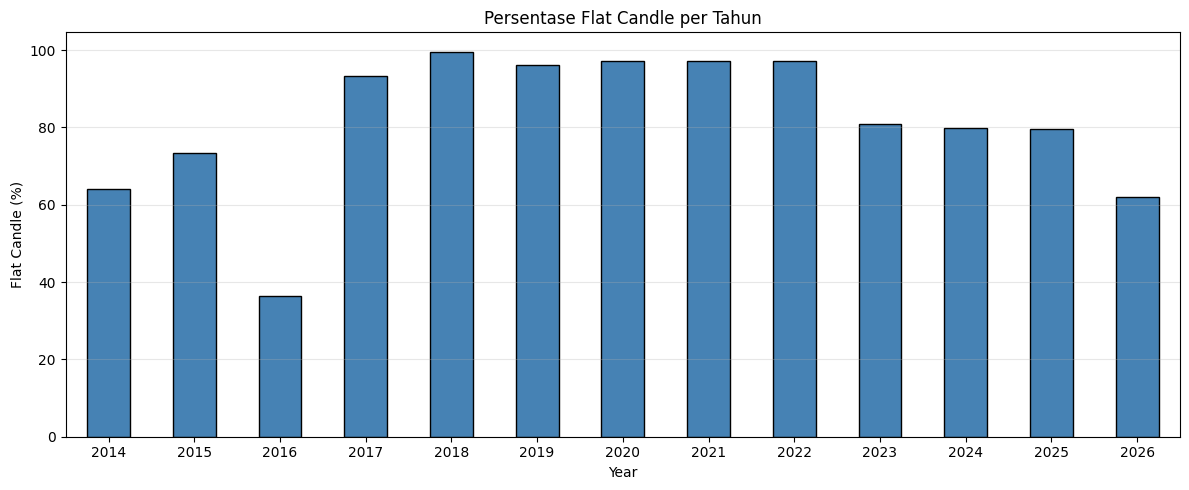


IMPLIKASI:
   • Data ini adalah settlement-style (1 harga/hari)
   • Open/High/Low = Close (disalin, bukan trading intraday)
   • Tidak cocok untuk analisis candlestick
   • Masih OK untuk forecasting return/price


In [4]:
# Deteksi flat candle (O=H=L=C)
flat_mask = (df['Open'] == df['High']) & (df['High'] == df['Low']) & (df['Low'] == df['Close'])
flat_count = flat_mask.sum()
flat_pct = round(flat_count / len(df) * 100, 2)

print("SETTLEMENT-STYLE DATA (FLAT CANDLE)")
print("="*50)
print(f"Flat candle: {flat_count} hari ({flat_pct}%)")
print(f"   Normal candle: {len(df) - flat_count} hari ({100-flat_pct:.2f}%)")

# Per tahun
df_temp = df.copy()
df_temp['Year'] = df_temp.index.year
df_temp['Is_Flat'] = flat_mask
flat_by_year = df_temp.groupby('Year')['Is_Flat'].mean() * 100

print("\nFlat Candle per Tahun:")
for year, pct in flat_by_year.items():
    bar = '█' * int(pct/5)
    print(f"   {year}: {pct:.1f}% {bar}")

# Visualisasi
plt.figure(figsize=(12, 5))
flat_by_year.plot(kind='bar', color='steelblue', edgecolor='black')
plt.xlabel('Year')
plt.ylabel('Flat Candle (%)')
plt.title('Persentase Flat Candle per Tahun')
plt.xticks(rotation=0)
plt.grid(axis='y', alpha=0.3)
plt.tight_layout()
plt.show()

print("\nIMPLIKASI:")
print("   • Data ini adalah settlement-style (1 harga/hari)")
print("   • Open/High/Low = Close (disalin, bukan trading intraday)")
print("   • Tidak cocok untuk analisis candlestick")
print("   • Masih OK untuk forecasting return/price")

### 2.4 Stale / Plateau Behavior

In [5]:
# Deteksi streak harga konstan
df_temp = df.copy()
df_temp['Price_Changed'] = (df_temp['Close'] != df_temp['Close'].shift(1)).astype(int)
df_temp['Streak_Group'] = (df_temp['Price_Changed'] != df_temp['Price_Changed'].shift(1)).cumsum()
df_temp['Streak_Length'] = df_temp.groupby('Streak_Group').cumcount() + 1

# Cari streak ≥5 hari
long_streaks = df_temp[df_temp['Price_Changed'] == 0].groupby('Streak_Group').size()
runs_ge_5 = (long_streaks >= 5).sum()
max_streak = long_streaks.max() if len(long_streaks) > 0 else 0

# Return = 0
df_temp['Return'] = df_temp['Close'].pct_change(fill_method=None)
zero_return = (df_temp['Return'] == 0).sum()
zero_return_pct = round(zero_return / len(df) * 100, 2)

print("STALE / PLATEAU BEHAVIOR")
print("="*50)
print(f"Run dengan ≥5 hari konstan: {runs_ge_5} run")
print(f"Streak terpanjang: ~{max_streak} hari")
print(f"Hari dengan return = 0: {zero_return} ({zero_return_pct}%)")

# Tampilkan streak terpanjang
if max_streak >= 5:
    longest_streak_group = long_streaks[long_streaks == max_streak].index[0]
    streak_data = df_temp[df_temp['Streak_Group'] == longest_streak_group]
    print(f"\nStreak terpanjang:")
    print(f"   Dari: {streak_data.index.min().date()}")
    print(f"   Sampai: {streak_data.index.max().date()}")
    print(f"   Harga: {streak_data['Close'].iloc[0]}")

STALE / PLATEAU BEHAVIOR
Run dengan ≥5 hari konstan: 17 run
Streak terpanjang: ~89 hari
Hari dengan return = 0: 480 (16.11%)

Streak terpanjang:
   Dari: 2019-02-20
   Sampai: 2019-06-26
   Harga: 2225.0


#### Tabel Lengkap 17 Run Streak (≥5 Hari Konstan)

In [6]:
# Fungsi untuk ekstrak semua streak ≥5 hari
def extract_streaks(df, min_streak=5):
    """Extract semua streak periode dengan harga konstan"""
    df_temp = df.copy()
    df_temp['Price_Changed'] = (df_temp['Close'] != df_temp['Close'].shift(1)).astype(int)
    df_temp['Streak_Group'] = (df_temp['Price_Changed'] != df_temp['Price_Changed'].shift(1)).cumsum()
    
    # Group streak
    streak_groups = df_temp[df_temp['Price_Changed'] == 0].groupby('Streak_Group')
    streak_lengths = streak_groups.size()
    
    # Filter streak ≥ min_streak
    long_streaks = streak_lengths[streak_lengths >= min_streak]
    
    # Ekstrak detail setiap streak
    streak_details = []
    for i, (group_id, length) in enumerate(long_streaks.items(), 1):
        group_data = df_temp[df_temp['Streak_Group'] == group_id]
        start_date = group_data.index.min()
        end_date = group_data.index.max()
        price = group_data['Close'].iloc[0]
        
        # Kategorikan
        if length >= 30:
            kategori = "Streak sangat panjang"
        elif length >= 10:
            kategori = "Streak panjang"
        else:
            kategori = "Streak pendek"
        
        # Cek jika ini missing data
        if pd.isna(price):
            kategori = "Missing data block"
        
        streak_details.append({
            '#': i,
            'Start Date': start_date,
            'End Date': end_date,
            'Durasi (Hari)': length,
            'Harga Close': price,
            'Keterangan': kategori
        })
    
    return pd.DataFrame(streak_details)

# Ekstrak dan tampilkan tabel
streak_table = extract_streaks(df, min_streak=5)

# Tampilkan dengan styling
print("="*100)
print("TABEL LENGKAP 17 RUN STREAK (≥5 Hari Konstan)")
print("="*100)
print(f"\nTotal run: {len(streak_table)} periode")
print(f"Total hari dalam streak: {streak_table['Durasi (Hari)'].sum()} hari ({streak_table['Durasi (Hari)'].sum()/len(df)*100:.2f}% dari data)")
print(f"\nStreak terpanjang: {streak_table['Durasi (Hari)'].max()} hari")
print(f"Rata-rata durasi: {streak_table['Durasi (Hari)'].mean():.1f} hari\n")
print("-"*100)

# Display tabel
display(streak_table.style.set_properties(**{
    'text-align': 'center',
    'border': '1px solid black'
}).format({
    'Start Date': lambda x: x.strftime('%Y-%m-%d') if pd.notna(x) else 'NaT',
    'End Date': lambda x: x.strftime('%Y-%m-%d') if pd.notna(x) else 'NaT',
    'Harga Close': lambda x: f"{x:,.2f}" if pd.notna(x) else 'NaN'
}).background_gradient(subset=['Durasi (Hari)'], cmap='YlOrRd'))

# Highlight streak terpanjang
max_streak_idx = streak_table['Durasi (Hari)'].idxmax()
print(f"\nSTREAK TERPANJANG: {streak_table.loc[max_streak_idx, 'Start Date'].strftime('%Y-%m-%d')} s/d {streak_table.loc[max_streak_idx, 'End Date'].strftime('%Y-%m-%d')}")
print(f"Durasi: {streak_table.loc[max_streak_idx, 'Durasi (Hari)']} hari dengan harga {streak_table.loc[max_streak_idx, 'Harga Close']}")

TABEL LENGKAP 17 RUN STREAK (≥5 Hari Konstan)

Total run: 17 periode
Total hari dalam streak: 416 hari (13.96% dari data)

Streak terpanjang: 89 hari
Rata-rata durasi: 24.5 hari

----------------------------------------------------------------------------------------------------


,#,Start Date,End Date,Durasi (Hari),Harga Close,Keterangan
0,1,2017-10-10,2017-10-16,5,"2,236.25",Streak pendek
1,2,2017-10-20,2017-10-27,6,"2,225.00",Streak pendek
2,3,2017-10-31,2017-11-28,20,"2,231.50",Streak panjang
3,4,2017-11-30,2017-12-27,19,"2,239.50",Streak panjang
4,5,2017-12-29,2018-01-26,19,"2,244.50",Streak panjang
5,6,2018-01-31,2018-02-26,18,"2,250.00",Streak panjang
6,7,2018-02-28,2018-03-27,20,"2,255.00",Streak panjang
7,8,2018-04-03,2018-05-29,40,"2,300.00",Streak sangat panjang
8,9,2018-05-31,2018-06-27,20,"2,305.00",Streak panjang
9,10,2018-06-29,2018-07-27,20,"2,309.25",Streak panjang



STREAK TERPANJANG: 2019-02-20 s/d 2019-06-26
Durasi: 89 hari dengan harga 2225.0


### 2.5 Outlier Detection

OUTLIER DETECTION (Return)
Statistik Return:
   Mean:   0.0002 (0.02%)
   Std:    0.0123 (1.23%)
   Min:    -0.1820 (-18.20%)
   Max:    0.0691 (6.91%)

Outlier (IQR method):
   Total: 147 (4.93%)
   Bound: [-0.0237, 0.0240]

Top 5 Return Ekstrem:


,Close,Return
Date,,
2019-06-27,1820.0,-0.182022
2022-03-08,3485.5,-0.069417
2022-03-09,3286.5,-0.057094
2021-10-21,2935.5,-0.055730
2021-10-27,2716.5,-0.052329


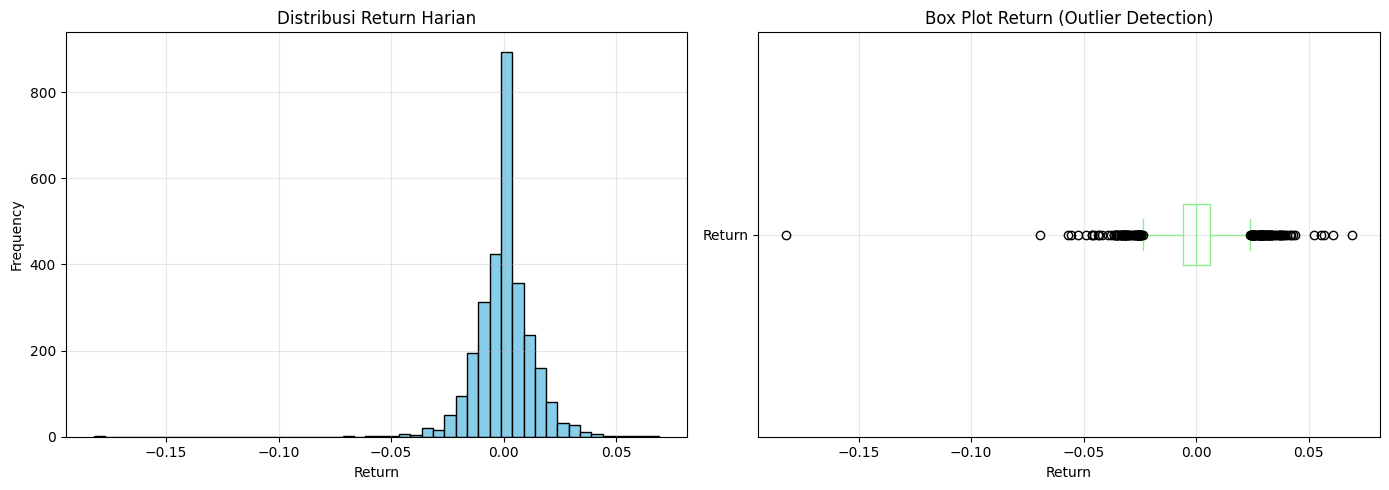


OUTLIER TERBESAR:
   Tanggal: 2019-06-27
   Return: -0.1820 (-18.20%)
   → Diduga artefak data (stale update)


In [7]:
# Hitung return
df_temp = df.copy()
df_temp['Return'] = df_temp['Close'].pct_change(fill_method=None)

# Outlier dengan IQR
Q1 = df_temp['Return'].quantile(0.25)
Q3 = df_temp['Return'].quantile(0.75)
IQR = Q3 - Q1
lower_bound = Q1 - 1.5 * IQR
upper_bound = Q3 + 1.5 * IQR

outliers = df_temp[(df_temp['Return'] < lower_bound) | (df_temp['Return'] > upper_bound)]
outlier_pct = round(len(outliers) / len(df) * 100, 2)

print("OUTLIER DETECTION (Return)")
print("="*50)
print(f"Statistik Return:")
print(f"   Mean:   {df_temp['Return'].mean():.4f} ({df_temp['Return'].mean()*100:.2f}%)")
print(f"   Std:    {df_temp['Return'].std():.4f} ({df_temp['Return'].std()*100:.2f}%)")
print(f"   Min:    {df_temp['Return'].min():.4f} ({df_temp['Return'].min()*100:.2f}%)")
print(f"   Max:    {df_temp['Return'].max():.4f} ({df_temp['Return'].max()*100:.2f}%)")
print(f"\nOutlier (IQR method):")
print(f"   Total: {len(outliers)} ({outlier_pct}%)")
print(f"   Bound: [{lower_bound:.4f}, {upper_bound:.4f}]")

# Top 5 outliers
print("\nTop 5 Return Ekstrem:")
top_outliers = df_temp.nsmallest(5, 'Return')[['Close', 'Return']]
display(top_outliers)

# Visualisasi
plt.figure(figsize=(14, 5))

plt.subplot(1, 2, 1)
df_temp['Return'].plot(kind='hist', bins=50, color='skyblue', edgecolor='black')
plt.xlabel('Return')
plt.title('Distribusi Return Harian')
plt.grid(alpha=0.3)

plt.subplot(1, 2, 2)
df_temp['Return'].plot(kind='box', vert=False, color='lightgreen')
plt.xlabel('Return')
plt.title('Box Plot Return (Outlier Detection)')
plt.grid(alpha=0.3)

plt.tight_layout()
plt.show()

# Highlight outlier terbesar
max_outlier_date = df_temp['Return'].idxmin()
max_outlier_val = df_temp.loc[max_outlier_date, 'Return']
print(f"\nOUTLIER TERBESAR:")
print(f"   Tanggal: {max_outlier_date.date()}")
print(f"   Return: {max_outlier_val:.4f} ({max_outlier_val*100:.2f}%)")
print(f"   → Diduga artefak data (stale update)" if max_outlier_val < -0.1 else "   → Pergerakan normal")

In [8]:
# ============================================
# ANALISIS LANJUTAN: OUTLIER & STALE DATA
# ============================================

print("ANALISIS LANJUTAN: HUBUNGAN OUTLIER, VOLUME, DAN STREAK")

# Siapkan data dengan return
df_analysis = df.copy()
df_analysis['Return'] = df_analysis['Close'].pct_change(fill_method=None)

# Hitung IQR untuk outlier
Q1 = df_analysis['Return'].quantile(0.25)
Q3 = df_analysis['Return'].quantile(0.75)
IQR = Q3 - Q1
lower_bound = Q1 - 1.5 * IQR
upper_bound = Q3 + 1.5 * IQR

# Identifikasi outlier
df_analysis['Is_Outlier'] = (df_analysis['Return'] < lower_bound) | (df_analysis['Return'] > upper_bound)

# Identifikasi volume = 0
df_analysis['Is_Zero_Volume'] = df_analysis['Volume'] == 0

# Identifikasi return = 0 (stale)
df_analysis['Is_Zero_Return'] = df_analysis['Return'] == 0

# 1. CEK: Berapa % outlier terjadi saat Volume=0?

outliers_df = df_analysis[df_analysis['Is_Outlier']].copy()
total_outliers = len(outliers_df)
outliers_zero_volume = (outliers_df['Is_Zero_Volume'] == True).sum()
pct_zero_volume = round(outliers_zero_volume / total_outliers * 100, 2)

print("\n" + "="*80)
print("1. OUTLIER vs VOLUME = 0")
print("="*80)
print(f"Total outlier: {total_outliers}")
print(f"Outlier dengan Volume = 0: {outliers_zero_volume} ({pct_zero_volume}%)")
print(f"Outlier dengan Volume > 0: {total_outliers - outliers_zero_volume} ({100-pct_zero_volume:.2f}%)")

if pct_zero_volume >= 40:
    print(f"\nTEMUAN: ~{pct_zero_volume:.0f}% outlier terjadi saat Volume=0")

ANALISIS LANJUTAN: HUBUNGAN OUTLIER, VOLUME, DAN STREAK

1. OUTLIER vs VOLUME = 0
Total outlier: 147
Outlier dengan Volume = 0: 73 (49.66%)
Outlier dengan Volume > 0: 74 (50.34%)

TEMUAN: ~50% outlier terjadi saat Volume=0


In [9]:
# 2. CEK: Deteksi streak dan outlier setelah streak berakhir

# Deteksi streak (hari dengan harga konstan)
df_analysis['Price_Changed'] = (df_analysis['Close'] != df_analysis['Close'].shift(1)).astype(int)
df_analysis['Streak_Group'] = (df_analysis['Price_Changed'] != df_analysis['Price_Changed'].shift(1)).cumsum()
df_analysis['Streak_Length'] = df_analysis.groupby('Streak_Group').cumcount() + 1

# Deteksi hari dimana streak berakhir (harga berubah setelah konstan)
df_analysis['Prev_Streak_Length'] = df_analysis['Streak_Length'].shift(1)
df_analysis['Is_Streak_End'] = (df_analysis['Price_Changed'] == 1) & (df_analysis['Prev_Streak_Length'] >= 5)

# 3. CEK: Outlier setelah streak panjang

print("\n" + "="*80)
print("2. OUTLIER SETELAH STREAK BERAKHIR")
print("="*80)

# Cari outlier yang terjadi tepat setelah streak berakhir
outliers_after_streak = df_analysis[
    (df_analysis['Is_Outlier']) & 
    (df_analysis['Is_Streak_End'])
][['Close', 'Return', 'Volume', 'Prev_Streak_Length']]

print(f"Total outlier setelah streak ≥5 hari: {len(outliers_after_streak)}")

if len(outliers_after_streak) > 0:
    print("\nDetail outlier setelah streak:")
    display(outliers_after_streak.sort_values('Return').head(10))
    
    # Highlight yang terbesar
    max_after_streak = outliers_after_streak['Return'].idxmin()
    print(f"\nOUTLIER TERBESAR SETELAH STREAK:")
    print(f"Tanggal: {max_after_streak.date()}")
    print(f"Return: {df_analysis.loc[max_after_streak, 'Return']:.4f} ({df_analysis.loc[max_after_streak, 'Return']*100:.2f}%)")
    print(f"Streak sebelumnya: {df_analysis.loc[max_after_streak, 'Prev_Streak_Length']} hari")


2. OUTLIER SETELAH STREAK BERAKHIR
Total outlier setelah streak ≥5 hari: 135

Detail outlier setelah streak:


,Close,Return,Volume,Prev_Streak_Length
Date,,,,
2019-06-27,1820.00,-0.182022,0,89.0
2022-03-08,3485.50,-0.069417,0,43.0
2022-03-09,3286.50,-0.057094,1,44.0
2021-10-21,2935.50,-0.055730,0,119.0
2021-10-27,2716.50,-0.052329,0,123.0
2019-02-19,2225.00,-0.046088,0,52.0
2025-10-10,2603.50,-0.045550,0,293.0
2022-08-30,2373.50,-0.043426,0,59.0
2022-03-29,3431.50,-0.042951,0,58.0



OUTLIER TERBESAR SETELAH STREAK:
Tanggal: 2019-06-27
Return: -0.1820 (-18.20%)
Streak sebelumnya: 89.0 hari


In [10]:
# 4. CEK: Detail outlier terbesar 2019-06-27

print("\n" + "="*80)
print("3. ANALISIS MENDALAM: OUTLIER 2019-06-27")
print("="*80)

# Tanggal outlier terbesar
max_outlier_date = df_analysis['Return'].idxmin()

# Tampilkan window ±15 hari sekitar outlier
window_start = max_outlier_date - pd.Timedelta(days=15)
window_end = max_outlier_date + pd.Timedelta(days=15)
window_data = df_analysis.loc[window_start:window_end, 
                               ['Close', 'Volume', 'Return', 'Streak_Length', 'Is_Zero_Volume']]

print(f"\nWindow: {window_start.date()} s/d {window_end.date()}")
print(f"\nStatistik window:")
print(f"Total hari: {len(window_data)}")
print(f"Hari dengan Volume=0: {(window_data['Is_Zero_Volume']==True).sum()}")
print(f"Hari dengan Return=0: {(window_data['Return']==0).sum()}")

print(f"\nDATA SEBELUM OUTLIER:")
pre_outlier = window_data[window_data.index < max_outlier_date]
if len(pre_outlier) > 0:
    max_streak_pre = pre_outlier['Streak_Length'].max()
    print(f"Streak terpanjang sebelum outlier: {max_streak_pre} hari")
    print(f"Harga selama streak: {pre_outlier.loc[pre_outlier['Streak_Length'].idxmax(), 'Close']}")

print(f"\nOUTLIER TERBESAR:")
print(f"Tanggal: {max_outlier_date.date()}")
print(f"Close: {df_analysis.loc[max_outlier_date, 'Close']}")
print(f"Return: {df_analysis.loc[max_outlier_date, 'Return']:.4f} ({df_analysis.loc[max_outlier_date, 'Return']*100:.2f}%)")
print(f"Volume: {df_analysis.loc[max_outlier_date, 'Volume']}")

# Cek apakah ini setelah streak panjang
streak_before = df_analysis.loc[max_outlier_date, 'Prev_Streak_Length']
print(f"\nKONTEKS STREAK:")
print(f"Streak sebelum outlier: {streak_before} hari")


3. ANALISIS MENDALAM: OUTLIER 2019-06-27

Window: 2019-06-12 s/d 2019-07-12

Statistik window:
Total hari: 22
Hari dengan Volume=0: 22
Hari dengan Return=0: 12

DATA SEBELUM OUTLIER:
Streak terpanjang sebelum outlier: 89 hari
Harga selama streak: 2225.0

OUTLIER TERBESAR:
Tanggal: 2019-06-27
Close: 1820.0
Return: -0.1820 (-18.20%)
Volume: 0

KONTEKS STREAK:
Streak sebelum outlier: 89.0 hari


In [11]:
# 5. CEK: IQR hanya pada return non-zero

print("\n" + "="*80)
print("4. IQR HANYA PADA RETURN NON-ZERO")
print("="*80)

# Filter hanya return non-zero
df_non_zero = df_analysis[df_analysis['Return'] != 0].copy()

# Hitung IQR baru
Q1_nz = df_non_zero['Return'].quantile(0.25)
Q3_nz = df_non_zero['Return'].quantile(0.75)
IQR_nz = Q3_nz - Q1_nz
lower_bound_nz = Q1_nz - 1.5 * IQR_nz
upper_bound_nz = Q3_nz + 1.5 * IQR_nz

# Hitung outlier dengan IQR baru
df_analysis['Is_Outlier_NZ'] = (df_analysis['Return'] < lower_bound_nz) | (df_analysis['Return'] > upper_bound_nz)
outliers_nz = df_analysis[df_analysis['Is_Outlier_NZ'] & (df_analysis['Return'] != 0)]

print(f"\nPERBANDINGAN IQR:")
print(f"\nIQR Standard (semua return):")
print(f"Q1: {Q1:.6f}")
print(f"Q3: {Q3:.6f}")
print(f"IQR: {IQR:.6f}")
print(f"Bound: [{lower_bound:.6f}, {upper_bound:.6f}]")
print(f"Total outlier: {total_outliers} ({round(total_outliers/len(df)*100, 2)}%)")

print(f"\nIQR Non-Zero Return (exclude return=0):")
print(f"Q1: {Q1_nz:.6f}")
print(f"Q3: {Q3_nz:.6f}")
print(f"IQR: {IQR_nz:.6f}")
print(f"Bound: [{lower_bound_nz:.6f}, {upper_bound_nz:.6f}]")
print(f"Total outlier: {len(outliers_nz)} ({round(len(outliers_nz)/len(df)*100, 2)}%)")

reduction = total_outliers - len(outliers_nz)
reduction_pct = round(reduction / total_outliers * 100, 2)

print(f"\nREDUKSI OUTLIER:")
print(f"Pengurangan: {reduction} outlier ({reduction_pct}% lebih sedikit)")


4. IQR HANYA PADA RETURN NON-ZERO

PERBANDINGAN IQR:

IQR Standard (semua return):
Q1: -0.005822
Q3: 0.006118
IQR: 0.011940
Bound: [-0.023733, 0.024028]
Total outlier: 147 (4.93%)

IQR Non-Zero Return (exclude return=0):
Q1: -0.007541
Q3: 0.008168
IQR: 0.015710
Bound: [-0.031106, 0.031732]
Total outlier: 70 (2.35%)

REDUKSI OUTLIER:
Pengurangan: 77 outlier (52.38% lebih sedikit)


## 3️. Univariate Analysis

DESCRIPTIVE STATISTICS


,Open,High,Low,Close,Volume
count,2941.000000,2941.000000,2941.000000,2941.000000,2980.000000
mean,2212.742435,2213.800663,2211.765131,2212.836450,8.059732
std,390.141511,390.298844,390.319308,390.388069,47.654603
min,1456.000000,1456.000000,1452.000000,1452.000000,0.000000
25%,1912.000000,1916.500000,1912.000000,1916.500000,0.000000
50%,2237.250000,2237.750000,2236.250000,2236.250000,0.000000
75%,2425.500000,2427.000000,2424.500000,2426.500000,6.000000
max,3873.000000,3873.000000,3873.000000,3873.000000,2210.000000


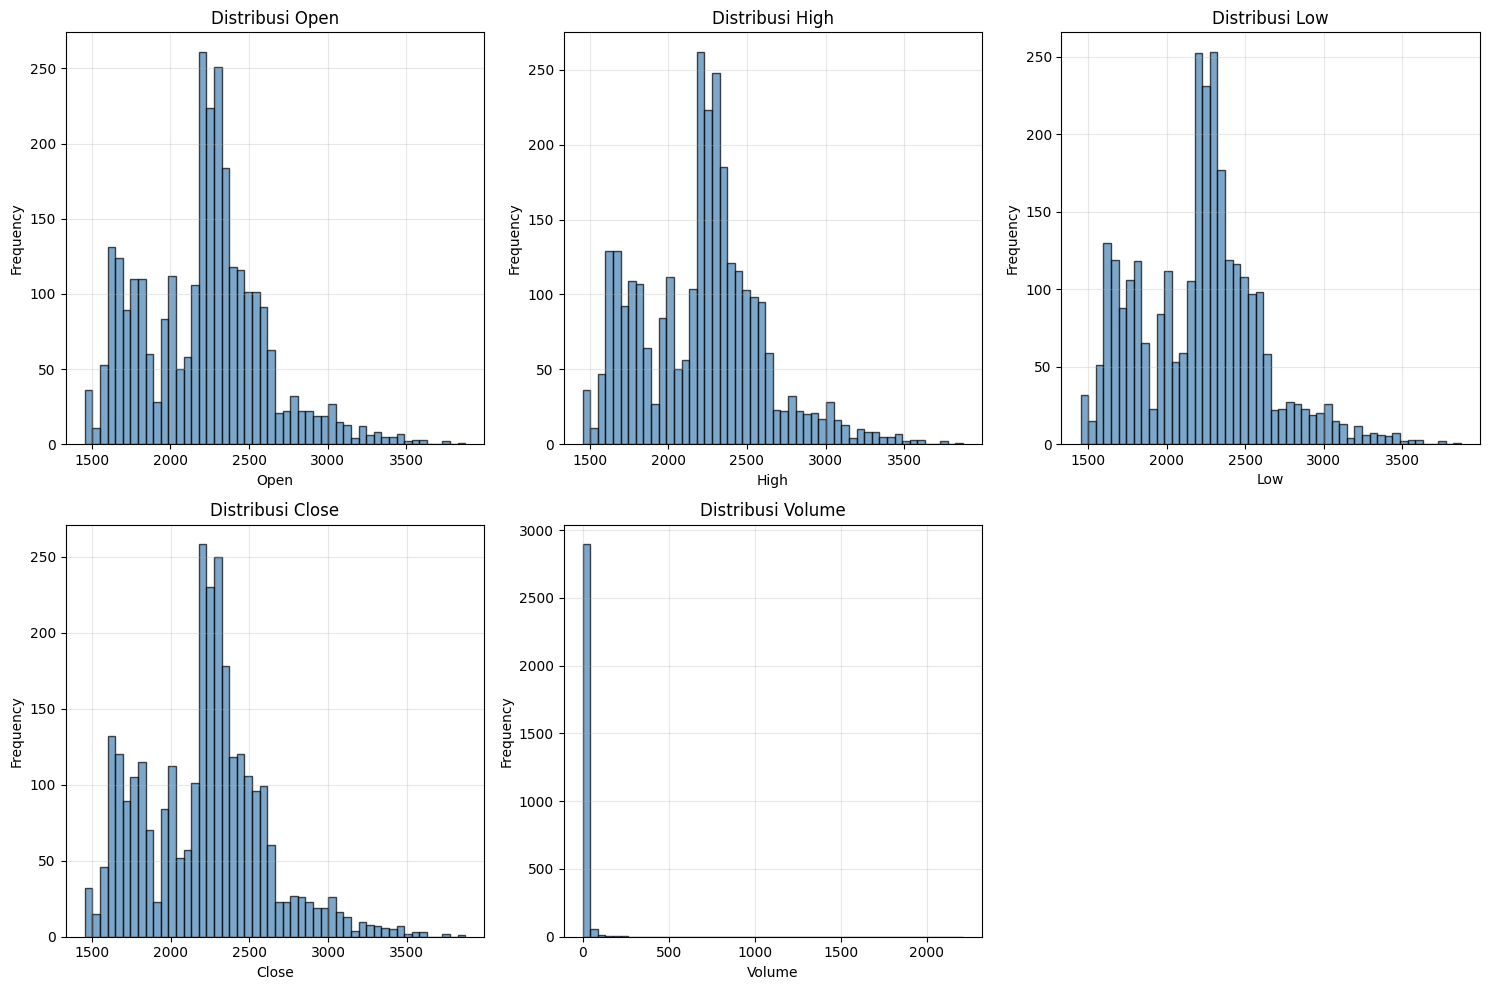

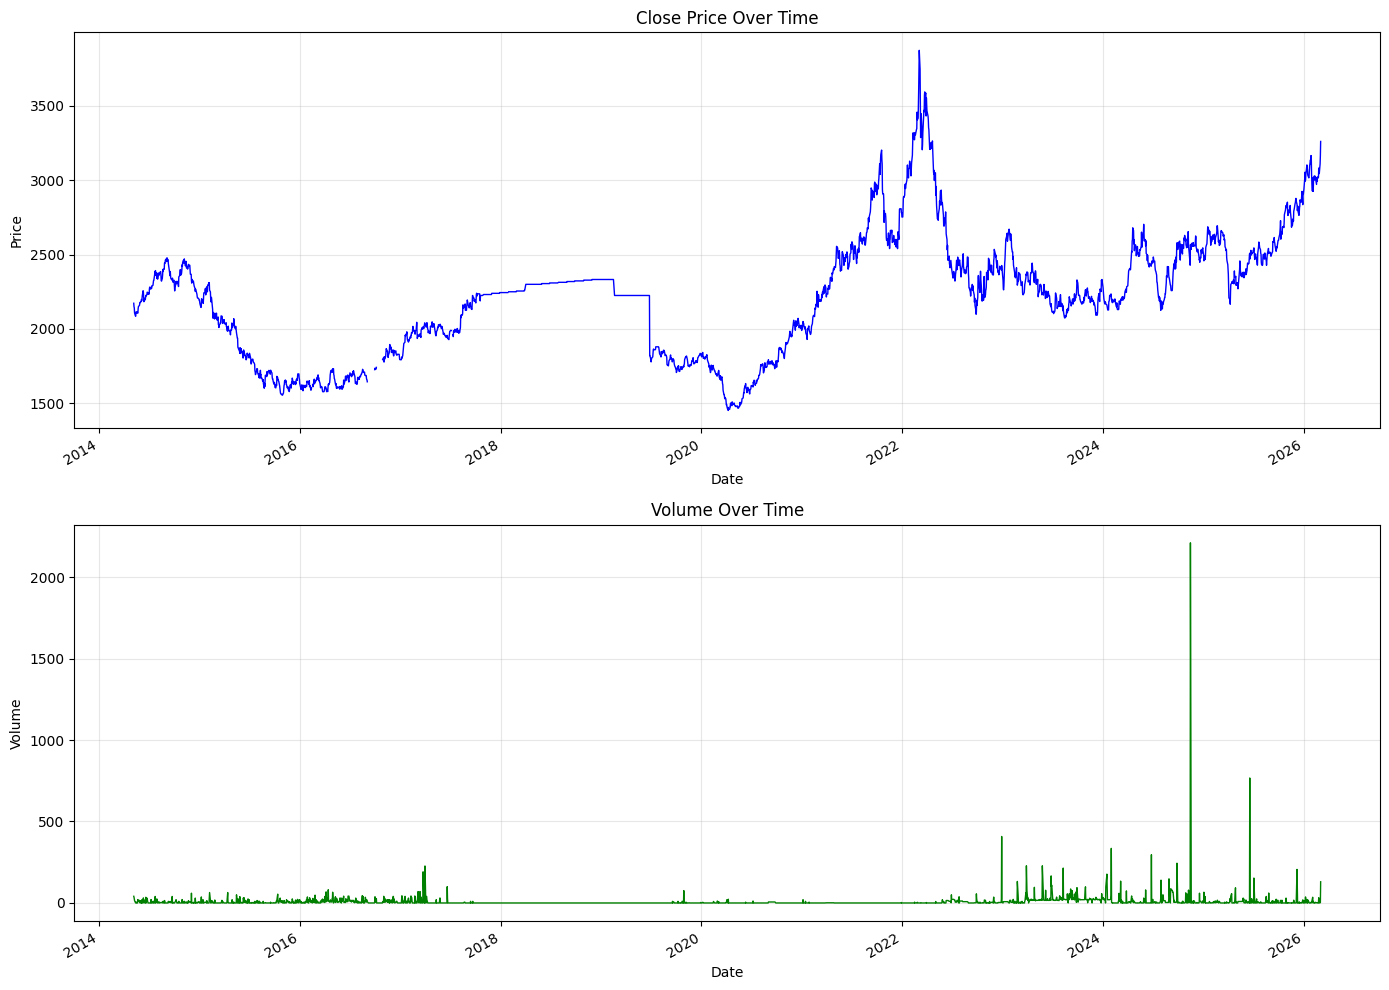

In [12]:
# Statistik deskriptif
print("DESCRIPTIVE STATISTICS")
print("="*60)
display(df[['Open', 'High', 'Low', 'Close', 'Volume']].describe())

# Visualisasi distribusi
fig, axes = plt.subplots(2, 3, figsize=(15, 10))
cols = ['Open', 'High', 'Low', 'Close', 'Volume']

for idx, col in enumerate(cols):
    ax = axes[idx // 3, idx % 3]
    df[col].plot(kind='hist', bins=50, ax=ax, color='steelblue', edgecolor='black', alpha=0.7)
    ax.set_xlabel(col)
    ax.set_title(f'Distribusi {col}')
    ax.grid(alpha=0.3)

# Kosongkan subplot terakhir
axes[1, 2].axis('off')

plt.tight_layout()
plt.show()

# Time series plot
fig, axes = plt.subplots(2, 1, figsize=(14, 10))

# Close price
df['Close'].plot(ax=axes[0], color='blue', linewidth=1)
axes[0].set_ylabel('Price')
axes[0].set_title('Close Price Over Time')
axes[0].grid(alpha=0.3)

# Volume
df['Volume'].plot(ax=axes[1], color='green', linewidth=1)
axes[1].set_ylabel('Volume')
axes[1].set_title('Volume Over Time')
axes[1].grid(alpha=0.3)

plt.tight_layout()
plt.show()

## 4️. Bivariate & Multivariate Analysis

CORRELATION MATRIX


,Open,High,Low,Close,Volume
Open,1.00,1.000,1.000,1.00,0.010
High,1.00,1.000,1.000,1.00,0.011
Low,1.00,1.000,1.000,1.00,0.009
Close,1.00,1.000,1.000,1.00,0.010
Volume,0.01,0.011,0.009,0.01,1.000


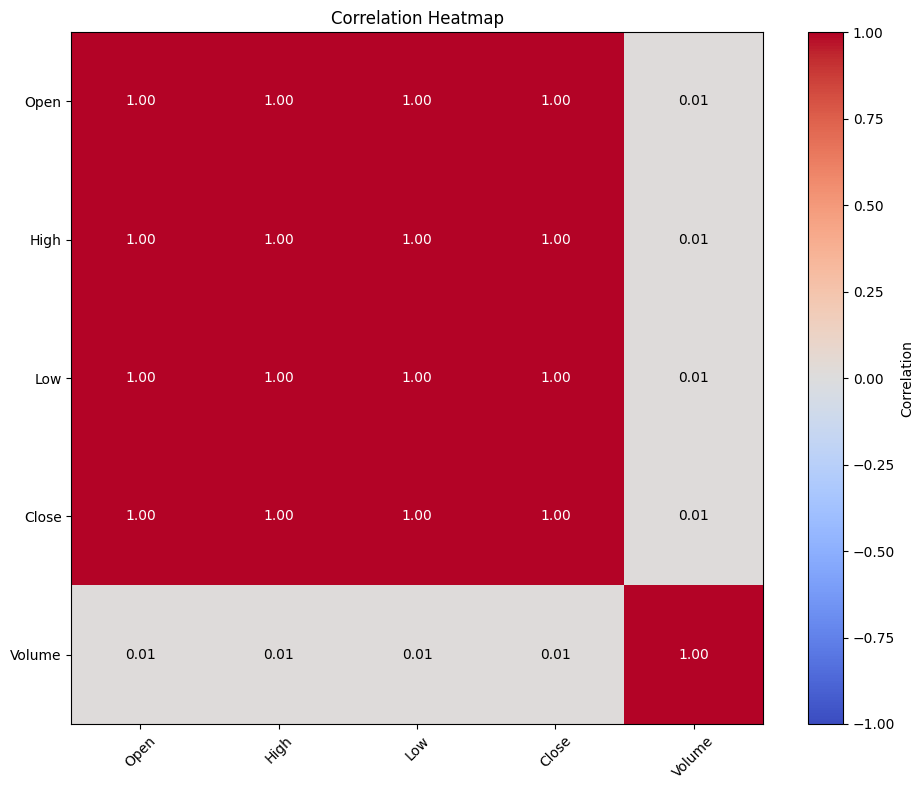


SCATTER PLOT MATRIX (sample 500 data)


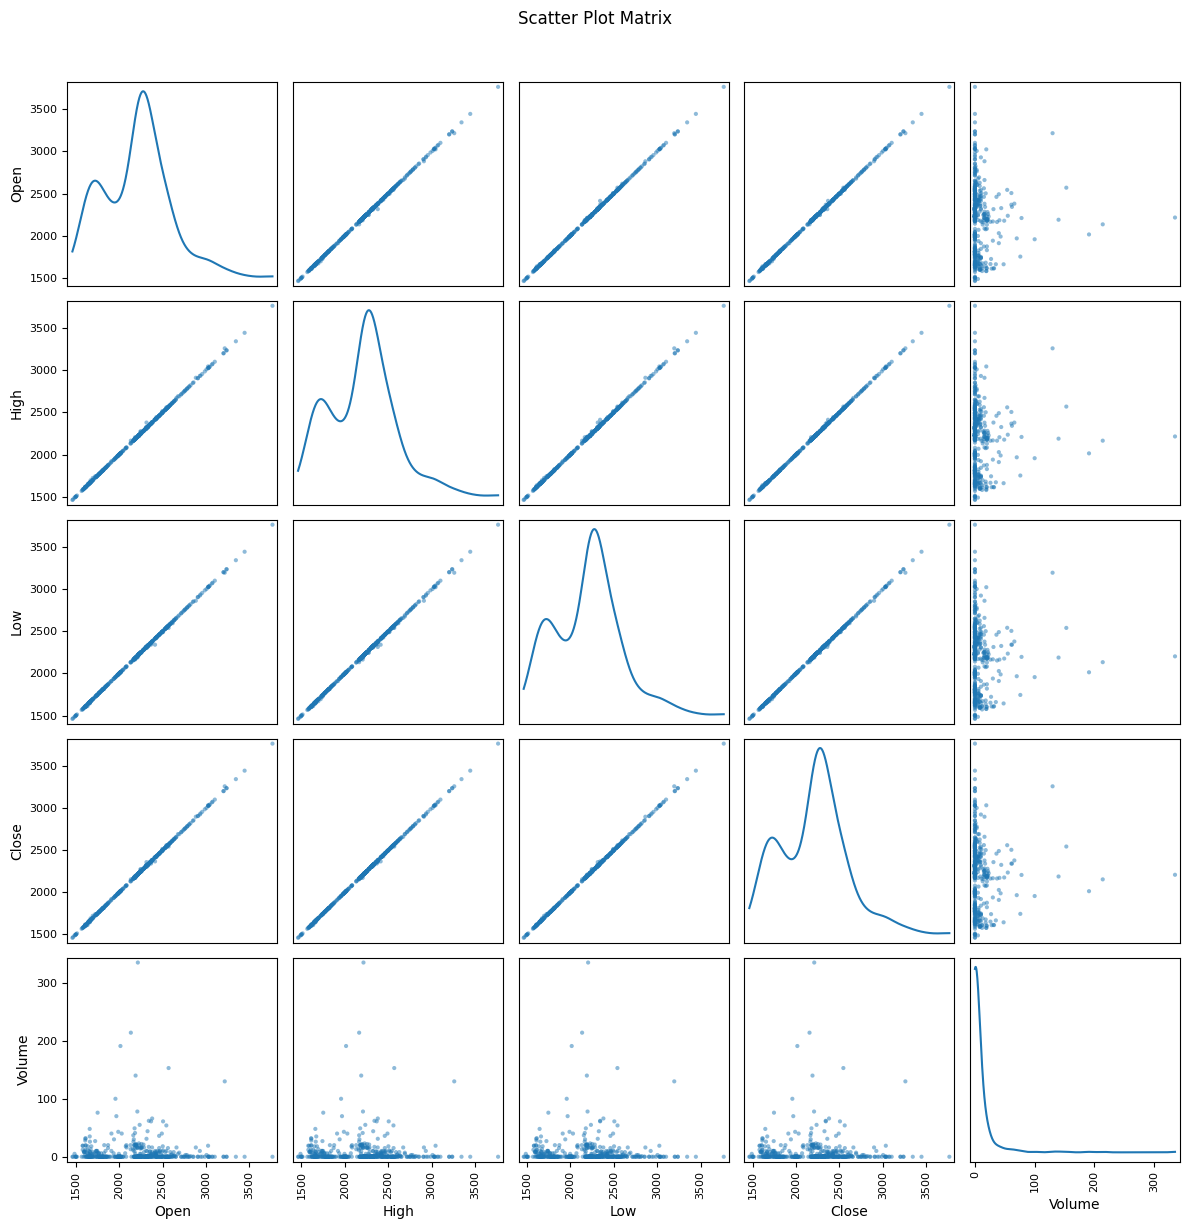

In [13]:
# Correlation matrix
print("CORRELATION MATRIX")
print("="*60)
corr_cols = ['Open', 'High', 'Low', 'Close', 'Volume']
corr_matrix = df[corr_cols].corr()
display(corr_matrix.round(3))

# Heatmap
plt.figure(figsize=(10, 8))
plt.imshow(corr_matrix, cmap='coolwarm', vmin=-1, vmax=1)
plt.colorbar(label='Correlation')
plt.xticks(range(len(corr_cols)), corr_cols, rotation=45)
plt.yticks(range(len(corr_cols)), corr_cols)
plt.title('Correlation Heatmap')

# Anotasi nilai
for i in range(len(corr_cols)):
    for j in range(len(corr_cols)):
        plt.text(j, i, f'{corr_matrix.iloc[i, j]:.2f}', 
                ha='center', va='center', 
                color='white' if abs(corr_matrix.iloc[i, j]) > 0.5 else 'black')

plt.tight_layout()
plt.show()

# Scatter plot matrix (sample untuk performa)
print("\nSCATTER PLOT MATRIX (sample 500 data)")
df_sample = df.sample(500, random_state=42)
pd.plotting.scatter_matrix(df_sample[corr_cols], figsize=(12, 12), alpha=0.5, diagonal='kde')
plt.suptitle('Scatter Plot Matrix', y=1.02)
plt.tight_layout()
plt.show()

PRICE vs VOLUME


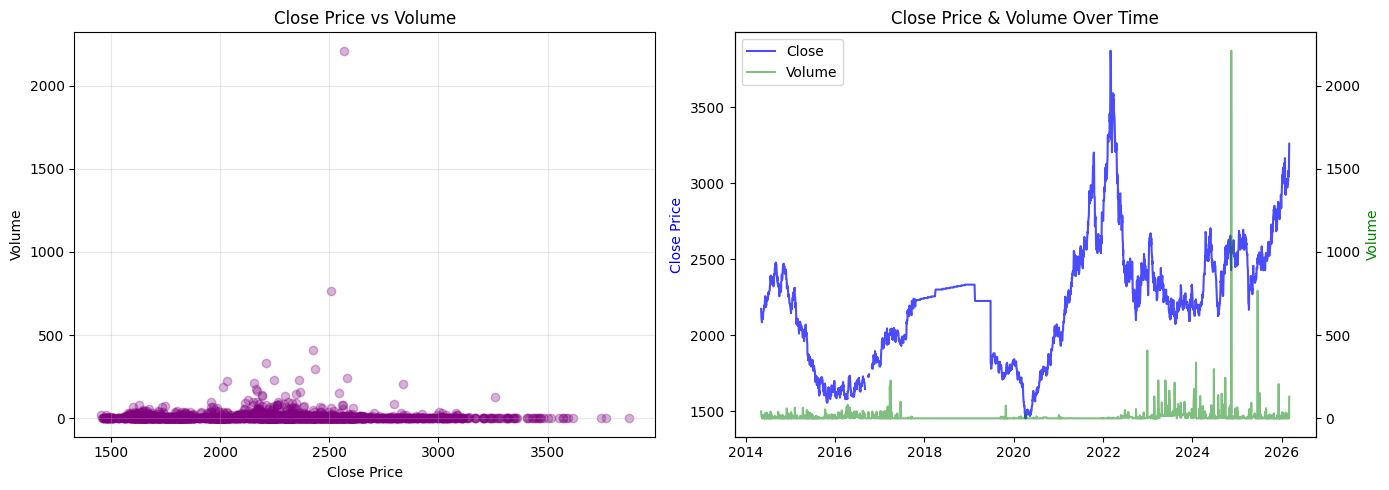

In [14]:
# Price vs Volume relationship
print("PRICE vs VOLUME")
print("="*60)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Scatter
axes[0].scatter(df['Close'], df['Volume'], alpha=0.3, color='purple')
axes[0].set_xlabel('Close Price')
axes[0].set_ylabel('Volume')
axes[0].set_title('Close Price vs Volume')
axes[0].grid(alpha=0.3)

# Time series dengan dual axis
ax1 = axes[1]
ax2 = ax1.twinx()

ax1.plot(df.index, df['Close'], color='blue', label='Close', alpha=0.7)
ax2.plot(df.index, df['Volume'], color='green', label='Volume', alpha=0.5)

ax1.set_ylabel('Close Price', color='blue')
ax2.set_ylabel('Volume', color='green')
ax1.set_title('Close Price & Volume Over Time')

# Legend
lines1, labels1 = ax1.get_legend_handles_labels()
lines2, labels2 = ax2.get_legend_handles_labels()
ax1.legend(lines1 + lines2, labels1 + labels2, loc='upper left')

plt.tight_layout()
plt.show()

## Deep Dive

### Step 2 — Basic Data Quality (Raw Snapshot)


In [15]:
from pathlib import Path
import pandas as pd
from IPython.display import display

# Prefer in-memory df if available, else fallback to raw file
df_raw = None
df_source = None

if 'df' in globals() and isinstance(df, pd.DataFrame):
    df_raw = df.copy()
    df_source = 'df (in-memory)'
else:
    candidate_paths = [
        Path('data/raw data/ali_f_raw.csv'),
        Path('../data/raw data/ali_f_raw.csv'),
        Path('../../data/raw data/ali_f_raw.csv'),
    ]
    raw_path = next((p for p in candidate_paths if p.exists()), None)
    if raw_path is None:
        print('Raw file not found in expected locations.')
        print('CWD:', Path.cwd())
    else:
        df_raw = pd.read_csv(raw_path, parse_dates=['Date'])
        df_raw = df_raw.set_index('Date').sort_index()
        df_source = str(raw_path)

if df_raw is None:
    print('Step 2 skipped: no data available.')
else:
    rows = len(df_raw)
    date_min = df_raw.index.min().date() if rows else None
    date_max = df_raw.index.max().date() if rows else None

    missing = df_raw.isna().sum()
    missing_pct = (missing / rows * 100).round(2) if rows else missing

    volume_zero = None
    volume_zero_pct = None
    if 'Volume' in df_raw.columns:
        volume_zero = int((df_raw['Volume'] == 0).sum())
        volume_zero_pct = round(volume_zero / rows * 100, 2) if rows else 0

    flat_candle_cnt = None
    flat_candle_pct = None
    if set(['Open','High','Low','Close']).issubset(df_raw.columns):
        valid = df_raw[['Open','High','Low','Close']].notna().all(axis=1)
        flat_candle = (
            (df_raw['Open'] == df_raw['High']) &
            (df_raw['High'] == df_raw['Low']) &
            (df_raw['Low'] == df_raw['Close']) &
            valid
        )
        flat_candle_cnt = int(flat_candle.sum())
        flat_candle_pct = round(flat_candle_cnt / rows * 100, 2) if rows else 0

    ret = df_raw['Close'].pct_change(fill_method=None)
    zero_ret = int((ret == 0).sum())
    zero_ret_pct = round(zero_ret / rows * 100, 2) if rows else 0

    print('BASIC DATA QUALITY')
    print('=' * 60)
    print(f'Source: {df_source}')
    print(f'Rows: {rows}')
    print(f'Date range: {date_min} to {date_max}')
    print('Missing Close: {} ({}%)'.format(missing.get('Close', 0), missing_pct.get('Close', 0)))
    if volume_zero is not None:
        print(f'Volume == 0: {volume_zero} ({volume_zero_pct:.2f}%)')
    if flat_candle_cnt is not None:
        print(f'Flat candles (O=H=L=C): {flat_candle_cnt} ({flat_candle_pct:.2f}%)')
    print(f'Zero returns: {zero_ret} ({zero_ret_pct:.2f}%)')

    missing_df = pd.DataFrame({
        'Missing Count': missing,
        'Percentage (%)': missing_pct
    })
    missing_nonzero = missing_df[missing_df['Missing Count'] > 0].sort_values('Percentage (%)', ascending=False)
    if not missing_nonzero.empty:
        display(missing_nonzero)
    else:
        print('No missing values.')


BASIC DATA QUALITY
Source: df (in-memory)
Rows: 2980
Date range: 2014-05-06 to 2026-03-04
Missing Close: 39 (1.31%)
Volume == 0: 1882 (63.15%)
Flat candles (O=H=L=C): 2477 (83.12%)
Zero returns: 480 (16.11%)


,Missing Count,Percentage (%)
Adj Close,39,1.31
Close,39,1.31
High,39,1.31
Low,39,1.31
Open,39,1.31


### Step 3 — Quality Flags (Stale, Flat, Volume=0)


In [16]:
import pandas as pd
from pathlib import Path

# Ensure df_raw is available (from Step 2). If not, fallback to df or file.
if 'df_raw' not in globals() or df_raw is None:
    if 'df' in globals() and isinstance(df, pd.DataFrame):
        df_raw = df.copy()
    else:
        candidate_paths = [
            Path('data/raw data/ali_f_raw.csv'),
            Path('../data/raw data/ali_f_raw.csv'),
            Path('../../data/raw data/ali_f_raw.csv'),
        ]
        raw_path = next((p for p in candidate_paths if p.exists()), None)
        if raw_path is None:
            raise FileNotFoundError('Raw file not found for Step 3.')
        df_raw = pd.read_csv(raw_path, parse_dates=['Date']).set_index('Date').sort_index()

# Build quality flags
df_q = df_raw.copy()

close = df_q['Close']
df_q['is_missing'] = close.isna()
df_q['is_stale'] = close.notna() & close.eq(close.shift(1))
df_q['price_changed'] = close.notna() & (~df_q['is_stale'])

# Streak group based on stale flag only (missing does not count as stale)
df_q['streak_group'] = (df_q['is_stale'] != df_q['is_stale'].shift(1)).cumsum()
streak_sizes = df_q[df_q['is_stale']].groupby('streak_group').size()
df_q['streak_len'] = df_q['streak_group'].map(streak_sizes).fillna(0).astype(int)

if 'Volume' in df_q.columns:
    df_q['volume_zero'] = df_q['Volume'] == 0
else:
    df_q['volume_zero'] = False

if set(['Open','High','Low','Close']).issubset(df_q.columns):
    valid = df_q[['Open','High','Low','Close']].notna().all(axis=1)
    df_q['flat_candle'] = (
        (df_q['Open'] == df_q['High']) &
        (df_q['High'] == df_q['Low']) &
        (df_q['Low'] == df_q['Close']) &
        valid
    )
else:
    df_q['flat_candle'] = False

print('STEP 3 SUMMARY')
print('=' * 60)
print('Missing Close:', int(df_q['is_missing'].sum()))
print('Stale days:', int(df_q['is_stale'].sum()))
print('Streak >=5 days:', int((df_q['streak_len'] >= 5).sum()))
print('Volume==0:', int(df_q['volume_zero'].sum()))
print('Flat candles:', int(df_q['flat_candle'].sum()))


STEP 3 SUMMARY
Missing Close: 39
Stale days: 480
Streak >=5 days: 416
Volume==0: 1882
Flat candles: 2477


### Step 4 — Long Streak Table (≥5 Hari Konstan)


In [17]:
import pandas as pd
import numpy as np

if 'df_q' not in globals():
    raise ValueError('df_q not found. Run Step 3 first.')

rows = []

# Stale streaks (Close unchanged)
streak_sizes = df_q[df_q['is_stale']].groupby('streak_group').size()
long_streaks = streak_sizes[streak_sizes >= 5]
for gid, length in long_streaks.items():
    g = df_q[df_q['streak_group'] == gid]
    start = g.index.min()
    end = g.index.max()
    price = g['Close'].iloc[0]
    if length >= 30:
        cat = 'Streak sangat panjang'
    elif length >= 10:
        cat = 'Streak panjang'
    else:
        cat = 'Streak pendek'
    rows.append({
        'Start Date': start,
        'End Date': end,
        'Durasi (Hari)': int(length),
        'Harga Close': price,
        'Keterangan': cat,
    })

# Missing blocks (Close NaN)
missing_group = (df_q['is_missing'] != df_q['is_missing'].shift(1)).cumsum()
missing_sizes = df_q[df_q['is_missing']].groupby(missing_group).size()
missing_long = missing_sizes[missing_sizes >= 5]
for gid, length in missing_long.items():
    g = df_q[missing_group == gid]
    start = g.index.min()
    end = g.index.max()
    rows.append({
        'Start Date': start,
        'End Date': end,
        'Durasi (Hari)': int(length),
        'Harga Close': np.nan,
        'Keterangan': 'Missing data block',
    })

streak_table = pd.DataFrame(rows)
if not streak_table.empty:
    streak_table = streak_table.sort_values('Start Date').reset_index(drop=True)
    streak_table.insert(0, '#', range(1, len(streak_table) + 1))

print('TOTAL LONG STREAKS (stale + missing):', len(streak_table))
display(streak_table)


TOTAL LONG STREAKS (stale + missing): 19


,#,Start Date,End Date,Durasi (Hari),Harga Close,Keterangan
0,1,2016-09-06,2016-09-28,17,NaN,Missing data block
1,2,2016-10-06,2016-10-27,15,NaN,Missing data block
2,3,2017-10-10,2017-10-16,5,2236.25,Streak pendek
3,4,2017-10-20,2017-10-27,6,2225.00,Streak pendek
4,5,2017-10-31,2017-11-28,20,2231.50,Streak panjang
5,6,2017-11-30,2017-12-27,19,2239.50,Streak panjang
6,7,2017-12-29,2018-01-26,19,2244.50,Streak panjang
7,8,2018-01-31,2018-02-26,18,2250.00,Streak panjang
8,9,2018-02-28,2018-03-27,20,2255.00,Streak panjang
9,10,2018-04-03,2018-05-29,40,2300.00,Streak sangat panjang


### Step 5 — Build Calendar vs Event Datasets


In [18]:
from pathlib import Path

if 'df_q' not in globals():
    raise ValueError('df_q not found. Run Step 3 first.')

# Calendar-based: keep all days + flags
df_calendar = df_q.copy()

# Event-based: keep only days where price changes AND Close is not missing
df_event = df_q[(~df_q['is_stale']) & (df_q['Close'].notna())].copy()

print('Calendar rows:', len(df_calendar))
print('Event rows:', len(df_event))

# Optional save
SAVE_OUTPUTS = True
if SAVE_OUTPUTS:
    out_dir = Path('data/processed data')
    out_dir.mkdir(parents=True, exist_ok=True)
    df_calendar.to_csv(out_dir / 'ali_f_calendar.csv')
    df_event.to_csv(out_dir / 'ali_f_event.csv')
    print('Saved:', out_dir / 'ali_f_calendar.csv')
    print('Saved:', out_dir / 'ali_f_event.csv')


Calendar rows: 2980
Event rows: 2461
Saved: data/processed data/ali_f_calendar.csv
Saved: data/processed data/ali_f_event.csv


### Step 6 — Outlier Detection (IQR + Rolling MAD)


In [19]:
import numpy as np

if 'df_q' not in globals():
    raise ValueError('df_q not found. Run Step 3 first.')

df_q['Return'] = df_q['Close'].pct_change(fill_method=None)
ret = df_q['Return']

# IQR outliers (global)
Q1 = ret.quantile(0.25)
Q3 = ret.quantile(0.75)
IQR = Q3 - Q1
lower = Q1 - 1.5 * IQR
upper = Q3 + 1.5 * IQR
df_q['is_outlier_iqr'] = (ret < lower) | (ret > upper)

# Rolling MAD outliers (robust)
window = 90
min_periods = 30
median = ret.rolling(window, min_periods=min_periods).median()
mad = (ret - median).abs().rolling(window, min_periods=min_periods).median()
mad = mad.replace(0, np.nan)
mad = mad.clip(lower=1e-6)
robust_z = 0.6745 * (ret - median) / mad
df_q['is_outlier_mad'] = robust_z.abs() > 5

print('IQR bounds:', round(lower, 4), 'to', round(upper, 4))
print('Outliers (IQR):', int(df_q['is_outlier_iqr'].sum()))
print('Outliers (MAD):', int(df_q['is_outlier_mad'].sum()))


IQR bounds: -0.0237 to 0.024
Outliers (IQR): 147
Outliers (MAD): 4


### Step 7 — Flag Suspect Outliers


In [20]:
import pandas as pd

if 'df_q' not in globals():
    raise ValueError('df_q not found. Run Step 3 first.')

# Identify next day after long stale streak end
streak_sizes = df_q[df_q['is_stale']].groupby('streak_group').size()
long_streak_groups = set(streak_sizes[streak_sizes >= 5].index)
last_day_mask = df_q['streak_group'].isin(long_streak_groups) & df_q['is_stale'] & (
    df_q['streak_group'] != df_q['streak_group'].shift(-1)
)
next_day_idx = df_q.index.to_series().shift(-1)[last_day_mask].dropna()
df_q['next_day_after_long_streak'] = df_q.index.isin(next_day_idx.values)

df_q['is_suspect_outlier'] = (df_q['is_outlier_iqr'] | df_q['is_outlier_mad']) & (
    df_q['volume_zero'] | df_q['next_day_after_long_streak']
)

print('Suspect outliers:', int(df_q['is_suspect_outlier'].sum()))

# Show top 10 suspect outliers (largest absolute return)
sus = df_q[df_q['is_suspect_outlier']].copy()
if not sus.empty:
    sus['abs_return'] = sus['Return'].abs()
    display(sus.sort_values('abs_return', ascending=False).head(10)[
        ['Close','Return','volume_zero','next_day_after_long_streak']
    ])
else:
    print('No suspect outliers found.')


Suspect outliers: 75


,Close,Return,volume_zero,next_day_after_long_streak
Date,,,,
2019-06-27,1820.00,-0.182022,True,True
2022-03-08,3485.50,-0.069417,True,False
2021-10-21,2935.50,-0.055730,True,False
2022-10-26,2352.50,0.055643,True,False
2022-11-11,2475.00,0.052520,True,False
2021-10-27,2716.50,-0.052329,True,False
2022-04-25,3054.50,-0.046363,True,False
2019-02-19,2225.00,-0.046088,True,True
2025-10-10,2603.50,-0.045550,True,False
